<a href="https://colab.research.google.com/github/2403a52009-bot/ML/blob/main/ml_Asn_12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Decision Tree vs AdaBoost vs Random Forest
### Credit Card Dataset Classification

Tasks performed:
1. Load dataset and preprocess features
2. Train baseline Decision Tree
3. Train AdaBoost and Random Forest
4. Tune Random Forest (`n_estimators`, `max_depth`)
5. Compare models using Accuracy, Precision, Recall, ROC‑AUC
6. Identify best performing model


In [ ]:
# Install libraries if needed
!pip install pandas scikit-learn matplotlib seaborn

In [ ]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv('UCI_Credit_Card.csv')
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [ ]:
# Basic preprocessing
df = df.drop(columns=['ID'], errors='ignore')

# Target variable
target_col = 'default.payment.next.month'

X = df.drop(columns=[target_col])
y = df[target_col]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)

(24000, 23) (6000, 23)


In [ ]:
# Evaluation utilities
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score

def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    return acc, prec, rec, auc

In [ ]:
# 1️⃣ Decision Tree (Baseline)
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

dt_results = evaluate_model(dt_model, X_test, y_test)
dt_results

(0.7145,
 0.36941813261163736,
 0.4114544084400904,
 np.float64(0.6074506323181914))

In [ ]:
# 2️⃣ AdaBoost
from sklearn.ensemble import AdaBoostClassifier

ada_model = AdaBoostClassifier(n_estimators=100, random_state=42)
ada_model.fit(X_train, y_train)

ada_results = evaluate_model(ada_model, X_test, y_test)
ada_results

(0.8171666666666667,
 0.6758409785932722,
 0.33308214016578747,
 np.float64(0.7685902161094431))

In [ ]:
# 3️⃣ Random Forest with different parameters
from sklearn.ensemble import RandomForestClassifier

results = []

n_estimators_list = [50, 100, 200]
max_depth_list = [None, 10, 20]

for n in n_estimators_list:
    for depth in max_depth_list:
        rf = RandomForestClassifier(
            n_estimators=n,
            max_depth=depth,
            random_state=42
        )
        rf.fit(X_train, y_train)

        acc, prec, rec, auc = evaluate_model(rf, X_test, y_test)

        results.append(["RandomForest", n, depth, acc, prec, rec, auc])

results

[['RandomForest',
  50,
  None,
  0.8118333333333333,
  0.6337837837837837,
  0.35342878673700073,
  np.float64(0.7478333178252594)],
 ['RandomForest',
  50,
  10,
  0.8176666666666667,
  0.666191155492154,
  0.3519216277317257,
  np.float64(0.771570104583547)],
 ['RandomForest',
  50,
  20,
  0.8145,
  0.646978021978022,
  0.3549359457422758,
  np.float64(0.7593314928985654)],
 ['RandomForest',
  100,
  None,
  0.812,
  0.6324900133155792,
  0.3579502637528259,
  np.float64(0.7505958244954782)],
 ['RandomForest',
  100,
  10,
  0.817,
  0.6614950634696756,
  0.35342878673700073,
  np.float64(0.7727062792862717)],
 ['RandomForest',
  100,
  20,
  0.8163333333333334,
  0.6547455295735901,
  0.35870384325546345,
  np.float64(0.7618268682942029)],
 ['RandomForest',
  200,
  None,
  0.8123333333333334,
  0.6310299869621904,
  0.36473247927656366,
  np.float64(0.7544770895221165)],
 ['RandomForest',
  200,
  10,
  0.8171666666666667,
  0.6652298850574713,
  0.34890730972117556,
  np.float64

In [ ]:
# Collect all model results
import pandas as pd

summary = pd.DataFrame(results, columns=[
    "Model","n_estimators","max_depth",
    "Accuracy","Precision","Recall","ROC_AUC"
])

summary.loc[len(summary)] = ["DecisionTree", None, None, *dt_results]
summary.loc[len(summary)] = ["AdaBoost", None, None, *ada_results]

summary

/tmp/ipykernel_939/2272336787.py:9: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  summary.loc[len(summary)] = ["DecisionTree", None, None, *dt_results]
/tmp/ipykernel_939/2272336787.py:10: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  summary.loc[len(summary)] = ["AdaBoost", None, None, *ada_results]


,Model,n_estimators,max_depth,Accuracy,Precision,Recall,ROC_AUC
0,RandomForest,50,NaN,0.811833,0.633784,0.353429,0.747833
1,RandomForest,50,10.0,0.817667,0.666191,0.351922,0.771570
2,RandomForest,50,20.0,0.814500,0.646978,0.354936,0.759331
3,RandomForest,100,NaN,0.812000,0.632490,0.357950,0.750596
4,RandomForest,100,10.0,0.817000,0.661495,0.353429,0.772706
5,RandomForest,100,20.0,0.816333,0.654746,0.358704,0.761827
6,RandomForest,200,NaN,0.812333,0.631030,0.364732,0.754477
7,RandomForest,200,10.0,0.817167,0.665230,0.348907,0.773306
8,RandomForest,200,20.0,0.815167,0.649725,0.356443,0.765527
9,DecisionTree,None,NaN,0.714500,0.369418,0.411454,0.607451


In [ ]:
# Identify best model
best_model = summary.sort_values("ROC_AUC", ascending=False).iloc[0]
best_model

,7
Model,RandomForest
n_estimators,200
max_depth,10.0
Accuracy,0.817167
Precision,0.66523
Recall,0.348907
ROC_AUC,0.773306


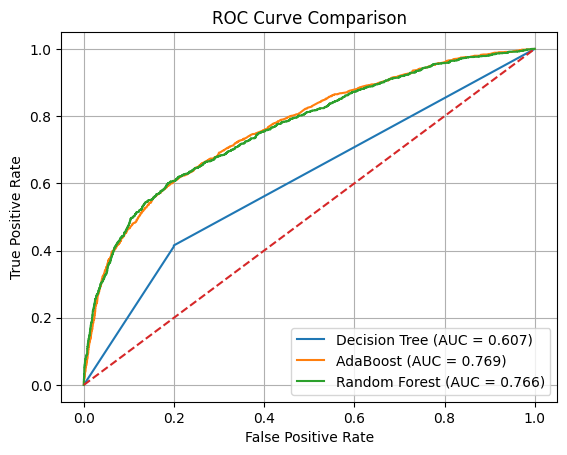

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

plt.figure()

# Decision Tree
dt_prob = dt_model.predict_proba(X_test)[:,1]
fpr_dt, tpr_dt, _ = roc_curve(y_test, dt_prob)
plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree (AUC = {roc_auc_score(y_test, dt_prob):.3f})")

# AdaBoost
ada_prob = ada_model.predict_proba(X_test)[:,1]
fpr_ada, tpr_ada, _ = roc_curve(y_test, ada_prob)
plt.plot(fpr_ada, tpr_ada, label=f"AdaBoost (AUC = {roc_auc_score(y_test, ada_prob):.3f})")

# Random Forest (use best RF model)
rf_model = RandomForestClassifier(n_estimators=200, max_depth=20, random_state=42)
rf_model.fit(X_train, y_train)

rf_prob = rf_model.predict_proba(X_test)[:,1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {roc_auc_score(y_test, rf_prob):.3f})")

# Diagonal reference line
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(True)
plt.show()

## Conclusion

- Decision Tree acts as the baseline.
- AdaBoost improves performance by combining weak learners sequentially.
- Random Forest improves stability using bagging and multiple trees.
- The best model is selected based on **highest ROC-AUC score** along with good Accuracy, Precision and Recall.